In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from src.util import read_video_frames, display_image, draw_bounding_box, render_scene, get_character_placeholder, pointcloud_to_mesh
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, get_masks_from_image_chunks
from src.operations3d import reconstruct_meshes_for_chunks, apply_mesh_transforms, adjust_transforms_by_chunk_rotation

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
video_path = "vids/moving_objects/wooden_cabinet.mp4"
frame_index = 0

object_class = "wooden_cabinet"

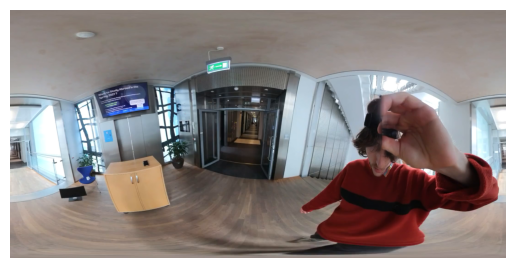

In [5]:
input_frame = read_video_frames(video_path)[frame_index]

display_image(input_frame)

# Single Class

Get panorama 2dbb and get image chunk

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes



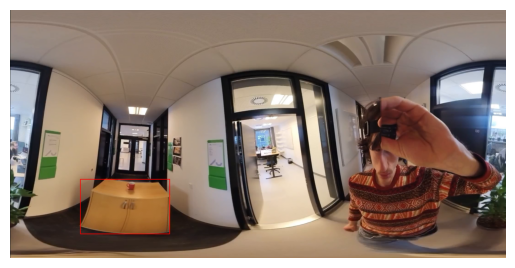

In [ ]:
# gpu
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class, use_gpu=True, threshold=0.7)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

display_image(frame_with_boxes)

In [6]:
# cpu
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cpu
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes




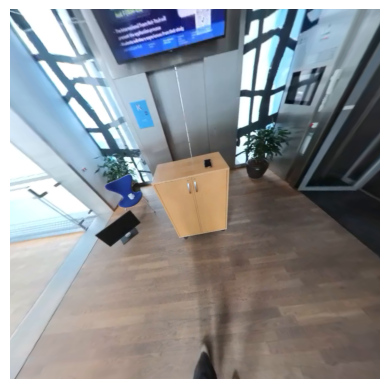

In [7]:
image_chunks = bounding_boxes_to_image_chunks(input_frame, bounding_boxes, orientation="horizontal")
display_image(image_chunks[0].image)

Get object masks

In [ ]:
# gpu
masks = get_masks_from_image_chunks(image_chunks, prompt=object_class, use_gpu=True)

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes



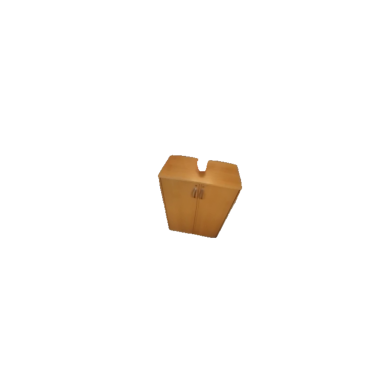

In [39]:
display_image(masks[0])

In [8]:
# cpu
masks = get_masks_from_image_chunks(image_chunks, prompt=object_class)

Running ovseg in conda environment 'ovseg'...
Loading OV-Seg model...
OV-Seg model loaded.
Processed chunk 1/1
Saved 1 masks




Generate meshes

In [ ]:
posed_meshes, unposed_meshes, rotations, translations = reconstruct_meshes_for_chunks(image_chunks, masks)

In [10]:
import pickle
pkl_path = "output/wooden_cabinet.pkl"
with open(pkl_path, "rb") as f:
    data = pickle.load(f)
frame_data = data[0]
reconstructed_data = frame_data["classes"][0]["reconstructed_meshes"][0]
unposed_mesh_path = reconstructed_data["unposed_mesh_path"]
translation = reconstructed_data["translation"]
rotation = reconstructed_data["rotation"]
print(unposed_mesh_path, translation, rotation)

output/reconstructed_meshes//wooden_cabinet/unposed_0.glb [0.002263713851581597, -1.0332958618161139, 0.7127585270655328] [[-0.9850533472772589, -0.006123026663993731, 0.17214114205415249], [0.010242102671297153, 0.995517690683367, 0.09401938803193187], [-0.17194523423391975, 0.09437719069427465, -0.9805752806004258]]


In [17]:
from src.util import read_trimesh, trimesh_to_open3d


unadjusted_mesh = read_trimesh(unposed_mesh_path)

In [19]:
adjusted_mesh = apply_mesh_transforms(unadjusted_mesh, rotation, translation)

In [ ]:
# Adjust transforms by chunk rotation and apply to unposed meshes
adjusted_rotations, adjusted_translations = adjust_transforms_by_chunk_rotation(rotations, translations, image_chunks[0])
adjusted_meshes = [apply_mesh_transforms(mesh, rot, trans) for mesh, rot, trans in zip(unposed_meshes, adjusted_rotations, adjusted_translations)]

In [13]:
adjusted_meshes = []

Render Scene

In [20]:
import open3d as o3d
from src.util import trimesh_to_open3d
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

unadjusted_mesh_o3d = trimesh_to_open3d(unadjusted_mesh).paint_uniform_color([1, 0, 0])  # Red for unadjusted mesh
adjusted_mesh_o3d = trimesh_to_open3d(adjusted_mesh).paint_uniform_color([0, 1, 0])  # Green for adjusted mesh

render_scene([unadjusted_mesh_o3d] + [adjusted_mesh_o3d] + [character_placeholder, coordinate_frame])

# Multiple Classes

In [ ]:
from src.tracking import reconstruct_meshes_for_class

In [ ]:
cupboard_meshes = adjusted_meshes

In [ ]:
cup_meshes = reconstruct_meshes_for_class(input_frame, "cup")

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cuda
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes

Running ovseg in conda environment 'ovseg'...
Loading OV-Seg model...
OV-Seg model loaded.
Processed chunk 1/1
Saved 1 masks

Running sam3d in conda environment 'sam3d-objects'...
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L4" (22 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/ucloud/.cache/warp/1.12.0
[SPARSE][CONV] spconv algo: auto
Saved point cloud 1/1 to temp/sam3d_output/reconstructed_mesh_0.ply
Generated 1 point clouds



In [ ]:
o3d.io.write_triangle_mesh("output/cup.glb", cup_meshes[0])

True

In [ ]:
all_meshes = cupboard_meshes + cup_meshes

In [ ]:
import open3d as o3d
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])

scene_meshes = all_meshes

render_scene(scene_meshes + [character_placeholder, coordinate_frame])